# 09 — State-Level Sales Performance
Rank all states by revenue and highlight profit margin to focus marketing investment.

## Setup — Spark Session & Load HDFS Tables

In [1]:
import os, sys

os.environ["JAVA_HOME"]             = "/usr/local/java"
os.environ["SPARK_HOME"]            = "/usr/local/spark"
os.environ["HADOOP_CONF_DIR"]       = "/usr/local/hadoop/etc/hadoop"
os.environ["PYSPARK_PYTHON"]        = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

import findspark
findspark.init()

from pyspark.sql import SparkSession

spark = SparkSession.getActiveSession()
if spark is None:
    spark = (SparkSession.builder
        .appName("09 — State-Level Sales Performance")
        .master("spark://namenode:7077")
        .config("spark.sql.shuffle.partitions", "4")
        .getOrCreate())

spark.sparkContext.setLogLevel("WARN")

HDFS_BASE = "hdfs:///data"

def load_csv(name, renames):
    df = (spark.read
          .option("header", "true")
          .option("inferSchema", "true")
          .csv(f"{HDFS_BASE}/{name}.csv"))
    for old, new in renames.items():
        df = df.withColumnRenamed(old, new)
    df.createOrReplaceTempView(name)
    return df

load_csv("customers",   {"Customer ID":"customer_id","Customer Name":"customer_name","Segment":"segment"})
load_csv("orders",      {"Order ID":"order_id","Order Date":"order_date","Ship Date":"ship_date",
                          "Ship Mode":"ship_mode","Customer ID":"customer_id","Postal Code":"postal_code"})
load_csv("order_items", {"Row ID":"row_id","Order ID":"order_id","Product ID":"product_id",
                          "Sales":"sales","Quantity":"quantity","Discount":"discount","Profit":"profit"})
load_csv("products",    {"Product ID":"product_id","Product Name":"product_name",
                          "Category":"category","Sub-Category":"sub_category"})
load_csv("locations",   {"Postal Code":"postal_code","City":"city","State":"state",
                          "Country":"country","Region":"region"})

import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

CHARTS_DIR = "/usr/local/hadoop/etc/hadoop/assessment-2/charts"
os.makedirs(CHARTS_DIR, exist_ok=True)
print("Ready.")


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/28 17:03:04 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
                                                                                

Ready.


## Query

In [2]:
df = spark.sql('''
    SELECT
        l.state, l.region,
        COUNT(DISTINCT o.order_id)                          AS total_orders,
        ROUND(SUM(oi.sales),  2)                            AS total_sales,
        ROUND(SUM(oi.profit), 2)                            AS total_profit,
        ROUND(SUM(oi.profit)/SUM(oi.sales)*100, 2)          AS margin_pct
    FROM orders o
    JOIN order_items oi ON o.order_id    = oi.order_id
    JOIN locations   l  ON o.postal_code = l.postal_code
    GROUP BY l.state, l.region ORDER BY total_sales DESC
''').toPandas()
top20   = df.head(20)
bottom10 = df.tail(10)
print(df.head())

          state   region  total_orders  total_sales  total_profit  margin_pct
0    California     West          1021    465333.76      77842.74       16.73
1      New York     East           562    310876.27      74038.55       23.82
2         Texas  Central           487    170188.05     -25729.36      -15.12
3    Washington     West           256    138641.27      33402.65       24.09
4  Pennsylvania     East           288    116511.91     -15559.96      -13.35


## Visualisation

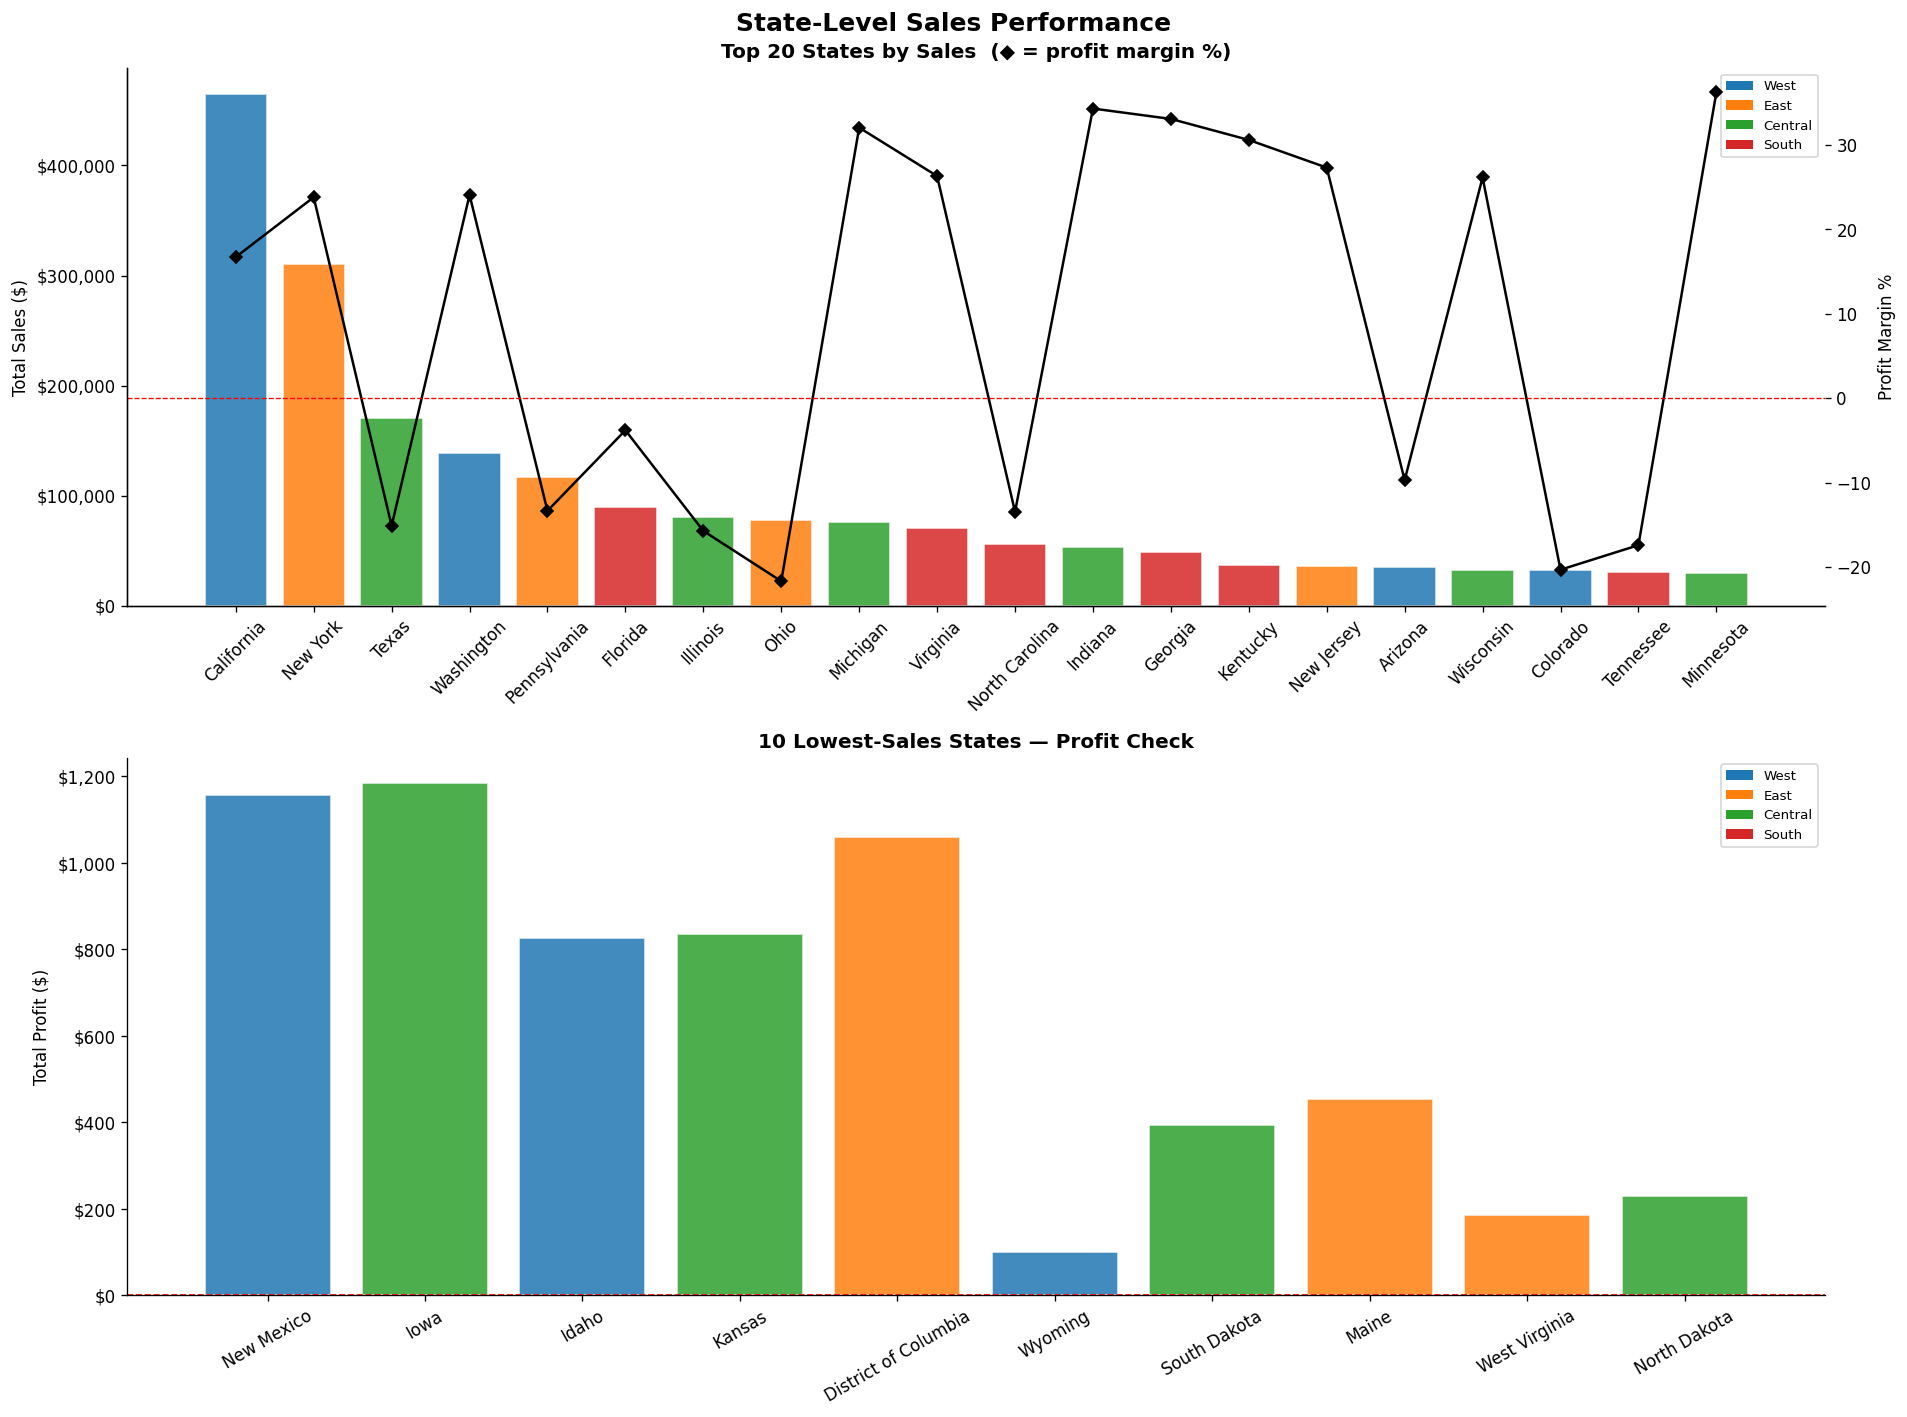

Chart saved to /usr/local/hadoop/etc/hadoop/assessment-2/charts/09_state_sales.png


In [3]:
from matplotlib.patches import Patch
reg_c = {"West":"#1f77b4","East":"#ff7f0e","Central":"#2ca02c","South":"#d62728"}
legend_els = [Patch(facecolor=v,label=k) for k,v in reg_c.items()]

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

ct = [reg_c.get(r,"#999") for r in top20["region"]]
axes[0].bar(top20["state"], top20["total_sales"], color=ct, alpha=0.85, edgecolor="white")
ax2 = axes[0].twinx()
ax2.plot(top20["state"], top20["margin_pct"], marker="D", color="black", lw=1.5, ms=5, label="Margin %")
ax2.axhline(0, color="red", lw=0.8, ls="--"); ax2.set_ylabel("Profit Margin %")
axes[0].set_title("Top 20 States by Sales  (◆ = profit margin %)", fontweight="bold")
axes[0].set_ylabel("Total Sales ($)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:,.0f}"))
axes[0].tick_params(axis="x", rotation=45); axes[0].legend(handles=legend_els, fontsize=8, loc="upper right")

cb = [reg_c.get(r,"#999") for r in bottom10["region"]]
axes[1].bar(bottom10["state"], bottom10["total_profit"], color=cb, alpha=0.85, edgecolor="white")
axes[1].axhline(0, color="red", lw=1, ls="--")
axes[1].set_title("10 Lowest-Sales States — Profit Check", fontweight="bold")
axes[1].set_ylabel("Total Profit ($)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:,.0f}"))
axes[1].tick_params(axis="x", rotation=30); axes[1].legend(handles=legend_els, fontsize=8)

plt.suptitle("State-Level Sales Performance", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.savefig(f"{CHARTS_DIR}/09_state_sales.png", bbox_inches="tight")
plt.show()
print(f"Chart saved to {CHARTS_DIR}/09_state_sales.png")

## Stop Spark

In [4]:
spark.stop()
print("Spark session stopped.")

Spark session stopped.
